In [ ]:
import seaborn as sns

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
}
sns.set_theme(context="notebook", style="ticks", rc=custom_params)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from typing import List, Tuple
import os
import json
import re
from matplotlib.cm import viridis
from matplotlib.colors import Normalize, LogNorm

# Extraction functions

In [ ]:
def parse_config(path: str) -> Tuple[List[np.ndarray], int]:
    """
    Parses .config files containing trajectories of particlrs in suspension at each time step.
    Arguments :
        path, the path to the config file.
    Returns :
        frames, lists of arrays of positions per time step.
        n_expected, the number of expected separate trajectorires.
    """
    frames: List[np.ndarray] = []
    n_expected = None

    with open(path, "r", encoding="utf-8") as f:
        lines = (ln.strip() for ln in f)
        while True:
            for ln in lines:
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) == 1 and parts[0].lstrip("-").isdigit():
                    n = int(parts[0])
                    if n <= 0:
                        raise ValueError(f"Invalid particle count: {n}")
                    if n_expected is None:
                        n_expected = n
                    elif n_expected != n:
                        raise ValueError(
                            f"Inconsistent particle count: {n} (expected {n_expected})"
                        )
                    break
                else:
                    raise ValueError(f"Expected particle count line, got: {ln}")
            else:
                break

            xyz = []
            for _ in range(n):
                try:
                    ln = next(lines).strip()
                except StopIteration:
                    raise ValueError("Unexpected EOF inside a timestep.")
                vals = ln.split()
                x, y, z = map(float, vals[:3])
                xyz.append((x, y, z))
            frames.append(np.asarray(xyz, dtype=float))
    return frames, n_expected


def frames_to_trajectories(frames: List[np.ndarray]) -> List[np.ndarray]:
    """
    Generates full trajectories from the frames.
    frames: list of arrays shaped (n,3) for each timestep.
    return: list of trajectories, each shaped (T,3), one per particle.
    """
    if not frames:
        raise ValueError("Where frames ???")
    n = frames[0].shape[0]
    arr = np.stack(frames, axis=0)  # (T, n, 3)
    return [arr[:, i, :] for i in range(n)]  # N [(T,3)]

# segmenting

In [ ]:
def split_by_z_threshold(
    trajs: List[np.ndarray],
    z_threshold: float,
    inclusive: bool = True,
    min_len: int = 3,
) -> List[List[np.ndarray]]:
    out: List[List[np.ndarray]] = []

    """
    Splits an individual xyz trajectory into segments based on a z criterion.
    Admits a minimal length to avoid micro trajectories polluting my stats.
    """
    for tr in trajs:
        z = tr[:, 2]
        active = (z <= z_threshold) if inclusive else (z < z_threshold)

        edges = np.flatnonzero(
            np.diff(np.r_[False, active, False])
        )  # i hate this function so much oh my god
        starts, ends = edges[0::2], edges[1::2]

        parts = []
        for s, e in zip(starts, ends):
            if e - s >= min_len:
                parts.append(tr[s:e].copy())
        out.append(parts)
    return out

# dedrifting

In [ ]:
import numpy as np
from typing import List


def dedrift_shear_x(
    trajs: List[np.ndarray], dt: float, gamma_dot: float, return_full: bool = False
) -> List[np.ndarray]:
    """Calculates the mean drift a single particle will feel at a single time step and subtraxts it.
    Reconstructs the final trajectory without the shear."""

    if not trajs:
        return []

    out = []
    for tr in trajs:
        tr = np.asarray(tr, dtype=float)
        if tr.ndim != 2 or tr.shape[1] < 3:
            # if nothing to correct
            out.append(tr if return_full else tr[..., 0])
            continue

        x = tr[:, 0]  # nothing to see along y
        z = tr[:, 2]

        if x.size < 2:
            # if nothing to diff/cumsum
            if return_full:
                out.append(tr.copy())
            else:
                out.append(x.copy())
            continue

        # Midpoint z between frames and dx
        z_mid = 0.5 * (z[1:] + z[:-1])
        dx = x[1:] - x[:-1]
        shear_dx = gamma_dot * z_mid * dt
        dx_corr = dx - shear_dx  # drift-removed step

        # Reconstruct corrected x by cumulative sum of corrected steps!
        x_corr = np.empty_like(x)
        x_corr[0] = x[0]
        x_corr[1:] = x[0] + np.cumsum(dx_corr)

        if return_full:
            tr2 = tr.copy()
            tr2[:, 0] = x_corr
            out.append(tr2)
        else:
            out.append(x_corr)

    return out  #

In [ ]:
def compute_average_msd(signal_list, dt):
    """Returns the MSD avg and std of a whole component."""
    lag_steps = np.hstack(
        [np.arange(10**i, 10 ** (i + 1), 10**i) for i in range(8)]
    ).astype(int)
    if lag_steps.size == 0:
        return (
            np.array([], dtype=float),
            np.array([], dtype=float),
            np.array([], dtype=float),
        )

    def msd_fixed(x, lags):
        x = np.asarray(x, dtype=float)
        msd = np.empty(len(lags), dtype=float)
        for n, lag in enumerate(lags):
            # mean over valid pairs
            diffs = x[lag:] - x[:-lag]
            msd[n] = np.nanstd(diffs) ** 2
        return msd

    all_msd = [msd_fixed(sig, lag_steps) for sig in signal_list]
    all_msd = np.vstack(all_msd)
    msd_avg = np.nanmean(all_msd, axis=0)
    msd_std = np.nanstd(all_msd, axis=0)
    return lag_steps * dt, msd_avg, msd_std


def compute_average_msd_nanpadding(signal_list, dt, min_coverage=0.3, max_decade=8):
    """
    Computes average MSD, padding with NaN.
    Keeps lags where at least min_coverage fraction of trajectories contribute.

    Returns:
      taus (seconds), mean_msd, sem_msd
    """
    if len(signal_list) == 0:
        return np.array([]), np.array([]), np.array([])

    N = len(signal_list)

    lag_steps = np.hstack(
        [np.arange(10**i, 10 ** (i + 1), 10**i) for i in range(max_decade)]
    ).astype(int)

    def msd_fixed(x, lags):
        x = np.asarray(x, float)
        out = np.full(len(lags), np.nan)
        for j, lag in enumerate(lags):
            if lag < len(x):
                d = x[lag:] - x[:-lag]
                out[j] = np.nanmean(d * d)
        return out

    all_msd = np.vstack([msd_fixed(s, lag_steps) for s in signal_list])

    valid_counts = np.sum(~np.isnan(all_msd), axis=0)

    keep = valid_counts >= np.ceil(min_coverage * N)
    lag_steps = lag_steps[keep]
    all_msd = all_msd[:, keep]

    if lag_steps.size == 0:
        return np.array([]), np.array([]), np.array([])

    # NaNmean and SEM
    mean_msd = np.nanmean(all_msd, axis=0)
    std_msd = np.nanstd(all_msd, axis=0)
    sem_msd = std_msd / np.sqrt(valid_counts[keep])

    taus = lag_steps * dt
    return taus, mean_msd, sem_msd

# computing the MSD per z bin

In [ ]:
def identify_trajectories_per_avg_height(
    signal_list, debye_height, evanescent_height, how_many_bins
):
    """
    Maps bin index to a list of trajectories.
    """
    avg_heights = np.array([np.mean(traj[:, 2]) for traj in signal_list])

    # bin_edges = np.logspace(start = np.log10(debye_height), stop = np.log10(evanescent_height), num = how_many_bins + 1, base=10.0)
    bin_edges = np.linspace(debye_height, evanescent_height, how_many_bins + 1)

    # print(bin_edges)

    bin_indices = np.digitize(avg_heights, bin_edges) - 1

    bin_indices = np.clip(bin_indices, 0, how_many_bins - 1)

    bins = {i: [] for i in range(how_many_bins)}

    for idx, traj in zip(bin_indices, signal_list):
        bins[idx].append(traj)

    return bins, bin_edges

In [ ]:
def get_component_signal(tr, comp):
    if isinstance(tr, dict):
        return np.asarray(tr[comp], dtype=float)
    comp_idx = {"x": 0, "y": 1, "z": 2}[comp]
    tr = np.asarray(tr)
    if tr.ndim == 2 and tr.shape[1] >= comp_idx + 1:
        return tr[:, comp_idx].astype(float)
    raise ValueError("Unrecognized trajectory format for get_component_signal func")


def average_msd_per_bin(bins, bin_edges, comp, dt):
    bin_indices = sorted(bins.keys())
    centers_all = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    bin_centers_subset, taus_list, msd_mean, msd_sem = [], [], [], []

    for b in bin_indices:
        group = bins[b]
        if not group:
            continue

        sigs = [get_component_signal(tr, comp) for tr in group]
        taus, avg, std = compute_average_msd_nanpadding(sigs, dt, min_coverage=0.3)

        if taus.size == 0:
            continue
        sem = std

        bin_centers_subset.append(centers_all[b])
        taus_list.append(taus)
        msd_mean.append(avg)
        msd_sem.append(sem)

    return np.array(bin_centers_subset), taus_list, msd_mean, msd_sem


def plot_all_segments(signals, comp, dt):
    plt.figure()
    for seg in signals:
        y = get_component_signal(seg, comp).astype(float)
        t = np.arange(len(y)) * dt
        plt.plot(t, y, alpha=0.8)

    plt.xlabel("Time (s)")
    plt.ylabel(f"{comp}(t)")
    plt.tight_layout()
    plt.show()

Amazing work juls !! Now, extract all D coefficients and their bin center and plot that.

In [ ]:
import math
import json


# logfit
def fit_log_msd_window(scales, msd, lower_bound_fit, upper_bound_fit):
    scales = np.asarray(scales, dtype=float)
    msd = np.asarray(msd, dtype=float)
    mask = (
        (scales >= lower_bound_fit)
        & (scales <= upper_bound_fit)
        & np.isfinite(msd)
        & (msd > 0)
    )
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    x_fit = np.log10(scales[mask])
    y_fit = np.log10(msd[mask])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_pred = slope * x_fit + intercept
    residuals = y_fit - y_pred
    dof = len(x_fit) - 2
    if dof <= 0:
        return slope, intercept, np.nan

    residual_std = np.sqrt(np.sum(residuals**2) / dof)
    denom = np.sqrt(np.sum((x_fit - np.mean(x_fit)) ** 2))
    intercept_std = residual_std / denom if denom > 0 else np.nan
    return slope, intercept, intercept_std


def save_D_per_height_json(results_dict, save_path, json_name="D_per_z.json"):
    """
    results_dict: { height: { 't_min','t_max','slope','intercept','D','stdD' }, ... }
    """
    if not save_path:
        return None
    os.makedirs(save_path, exist_ok=True)

    def _to_native(v):
        if isinstance(v, (np.floating, np.integer)):
            v = v.item()
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            return None
        return v

    out = {}
    for h in sorted(results_dict.keys()):
        vals = results_dict[h]
        out[str(_to_native(h))] = {
            "t_min": _to_native(vals.get("t_min")),
            "t_max": _to_native(vals.get("t_max")),
            "slope": _to_native(vals.get("slope")),
            "intercept": _to_native(vals.get("intercept")),
            "D": _to_native(vals.get("D")),
            "stdD": _to_native(vals.get("stdD")),
        }

    fp = os.path.join(save_path, json_name)
    with open(fp, "w") as jf:
        json.dump(out, jf, indent=2)
    return fp


def diffusion_coeffs_from_binned_msd(
    bin_centers,
    taus_list,
    msd_mean,
    t_min,
    t_max,
    return_arrays=False,
):
    results = {}
    H, Dvals, Derrs, Slopes = [], [], [], []
    tol = 0.02

    for c, taus, mean in zip(np.asarray(bin_centers, dtype=float), taus_list, msd_mean):
        slope, intercept, intercept_std = fit_log_msd_window(taus, mean, t_min, t_max)

        if np.isnan(intercept):
            D = np.nan
            stdD = np.nan
        else:
            D = 10.0**intercept / 2.0
            stdD = (
                (math.log(10) * (10.0**intercept) / 2.0) * intercept_std
                if np.isfinite(intercept_std)
                else np.nan
            )

        if (
            slope <= 1 - tol or slope >= 1 + tol
        ):  # garde fou for non-diffusive regimes to avoid extracting erroneous diffusion coefs
            D = np.nan
            stdD = np.nan

        results[c] = {
            "t_min": float(t_min),
            "t_max": float(t_max),
            "slope": float(slope) if np.isfinite(slope) else np.nan,
            "intercept": float(intercept) if np.isfinite(intercept) else np.nan,
            "D": float(D) if np.isfinite(D) else np.nan,
            "stdD": float(stdD) if np.isfinite(stdD) else np.nan,
        }

        H.append(c)
        Dvals.append(D)
        Derrs.append(stdD)
        Slopes.append(slope)
    print(results)
    if return_arrays:
        return results, np.array(H), np.array(Dvals), np.array(Derrs), np.array(Slopes)
    return results

Plot the MSDs with the fits :

In [ ]:
def plot_msd_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
):

    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    for c, taus, mean, sem in zip(bin_centers, taus_list, msd_mean, msd_sem):
        color = cmap(norm(c))
        ax.fill_between(taus, mean - sem, mean + sem, color=color, alpha=0.25)
        ax.plot(taus, mean, color=color, alpha=1)

    ax.set_xlabel("Lag time (s)")
    ax.set_ylabel("MSD")
    ax.set_xlim(1e-4, 5e-3)
    # ax.set_ylim(6e-4, 6e-3)

    ax.set_xscale("log")
    ax.set_yscale("log")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("z (um)")

    return fig, ax


def do_fit_MSD(bin_centers, taus_list, msd_mean, t_min, t_max, save_json_path):
    fit_results = diffusion_coeffs_from_binned_msd(
        bin_centers, taus_list, msd_mean, t_min=t_min, t_max=t_max, return_arrays=False
    )

    os.makedirs(os.path.dirname(save_json_path), exist_ok=True)
    save_D_per_height_json(
        fit_results,
        os.path.dirname(save_json_path),
        json_name=os.path.basename(save_json_path),
    )
    return fit_results

In [ ]:
def plot_diffusion_multiple_phi(json_name="D_per_height.json"):
    plt.figure(figsize=(8, 4))

    results = []
    for shear_dir in os.listdir("."):
        if os.path.isdir(shear_dir) and shear_dir.startswith("shear="):
            shear_match = re.search(r"shear=([0-9.+-eE]+)", shear_dir)
            if not shear_match:
                continue
            shear_val = float(shear_match.group(1))

            for phi_dir in os.listdir(shear_dir):
                phi_path = os.path.join(shear_dir, phi_dir)
                if os.path.isdir(phi_path) and phi_dir.startswith("phi="):
                    phi_match = re.search(r"phi=([0-9.+-eE]+)", phi_dir)
                    if not phi_match:
                        continue

                    phi_val = float(phi_match.group(1))

                    json_path = os.path.join(phi_path, json_name)
                    if not os.path.exists(json_path):
                        continue

                    with open(json_path, "r") as f:
                        data = json.load(f)

                    z = sorted(map(float, data.keys()))
                    D = [
                        np.nan if data[str(key)]["D"] is None else data[str(key)]["D"]
                        for key in z
                    ]

                    stdD = [
                        (
                            np.nan
                            if data[str(key)]["stdD"] is None
                            else data[str(key)]["stdD"]
                        )
                        for key in z
                    ]

                    results.append(
                        {
                            "shear": shear_val,
                            "phi": phi_val,
                            "z": z,
                            "D": D,
                            "stdD": stdD,
                        }
                    )

    phi_vals = np.array([r["phi"] for r in results])
    norm = LogNorm(vmin=min(phi_vals), vmax=max(phi_vals))
    cmap = plt.get_cmap("viridis")

    shear_vals = sorted(set(r["shear"] for r in results))
    markers = ["o", "s", "^"]
    marker_map = {s: markers[i % len(markers)] for i, s in enumerate(shear_vals)}

    for r in results:
        color = cmap(norm(r["phi"]))
        marker = marker_map[r["shear"]]
        label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"
        plt.errorbar(
            r["z"][:],
            r["D"][:],
            yerr=r["stdD"][:],
            fmt=marker,
            color=color,
            capsize=3,
            label=label,
            alpha=0.5,
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label(r"$\phi$ value")

    plt.xlabel(r"$z\;(\mu \mathrm{m})$")
    plt.ylabel(r"$D_y\;(\mu \mathrm{m}^2\,\mathrm{s}^{-1})$")
    plt.ylim(0, 5)
    plt.legend(frameon=False, fontsize=8, loc="lower right", ncols=2)
    plt.tight_layout()
    plt.savefig("Dyfz_colormap.pdf", transparent=True)
    plt.show()


def plot_D_curves_per_bin(
    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
):

    bin_centers = bin_centers / 0.055

    fig, ax = plt.subplots()
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(bin_centers), vmax=np.max(bin_centers))

    Dmean = [m / (2 * t) for m, t in zip(msd_mean, taus_list)]
    Dsem = [m / (2 * t) for m, t in zip(msd_sem, taus_list)]
    for c, taus, mean, sem in zip(bin_centers, taus_list, Dmean, Dsem):
        color = cmap(norm(c))
        ax.fill_between(taus, mean - sem, mean + sem, color=color, alpha=0.25)
        ax.plot(taus, mean, color=color, alpha=1)

    ax.set_xlabel(r"$\tau (s)$")
    ax.set_ylabel(r"MSD$/\tau (\mu \mathrm{m}^2.\mathrm{s}^{-1})$")
    ax.set_xlim(1e-4, 1e-2)
    ax.set_ylim(2, 5)

    ax.set_xscale("log")
    ax.set_yscale("log")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("$z/r$")

    return fig, ax

<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\d'
<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\d'
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_11583/3732725855.py:62: SyntaxWarning: invalid escape sequence '\p'
  label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_11583/3732725855.py:62: SyntaxWarning: invalid escape sequence '\d'
  label = f"$\phi={r['phi']}, \dot\gamma$={r['shear']}"


# Batch treating all phi dirs withing shear dirs

{np.float64(0.15000000000000002): {'t_min': 0.0001, 't_max': 0.001, 'slope': 1.0476902662714014, 'intercept': 0.6928596963194916, 'D': nan, 'stdD': nan}, np.float64(0.18333333333333335): {'t_min': 0.0001, 't_max': 0.001, 'slope': 1.1928284213138443, 'intercept': 1.5143134667524947, 'D': nan, 'stdD': nan}, np.float64(0.21666666666666667): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9617470111705397, 'intercept': 0.6685321267918334, 'D': nan, 'stdD': nan}, np.float64(0.25): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9930536120509309, 'intercept': 0.8110039075163153, 'D': 3.2357421918425606, 'stdD': 0.01418568555752744}, np.float64(0.2833333333333333): {'t_min': 0.0001, 't_max': 0.001, 'slope': 1.0050766482979585, 'intercept': 0.8629306646155677, 'D': 3.646705306023587, 'stdD': 0.024122976627183164}, np.float64(0.3166666666666667): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9714115126709143, 'intercept': 0.7385611517796002, 'D': nan, 'stdD': nan}, np.float64(0.35000000000000003): {'t

/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_11583/954523891.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


{np.float64(0.11666666666666667): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9641289877401351, 'intercept': 0.5430020267479587, 'D': nan, 'stdD': nan}, np.float64(0.15000000000000002): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9895170132557468, 'intercept': 0.6889988424861653, 'D': 2.4432552847604576, 'stdD': 0.02052205569183396}, np.float64(0.18333333333333335): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9913720074185098, 'intercept': 0.745590879068908, 'D': 2.7833055359374685, 'stdD': 0.0031892279079136355}, np.float64(0.21666666666666667): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9970419351725303, 'intercept': 0.8023379092413725, 'D': 3.1718154743646507, 'stdD': 0.008468690052828114}, np.float64(0.25): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9934843971712625, 'intercept': 0.8051349435159071, 'D': 3.192309187755018, 'stdD': 0.003955851287575307}, np.float64(0.2833333333333333): {'t_min': 0.0001, 't_max': 0.001, 'slope': 0.9905868831144035, 'intercept': 0.8097599355261

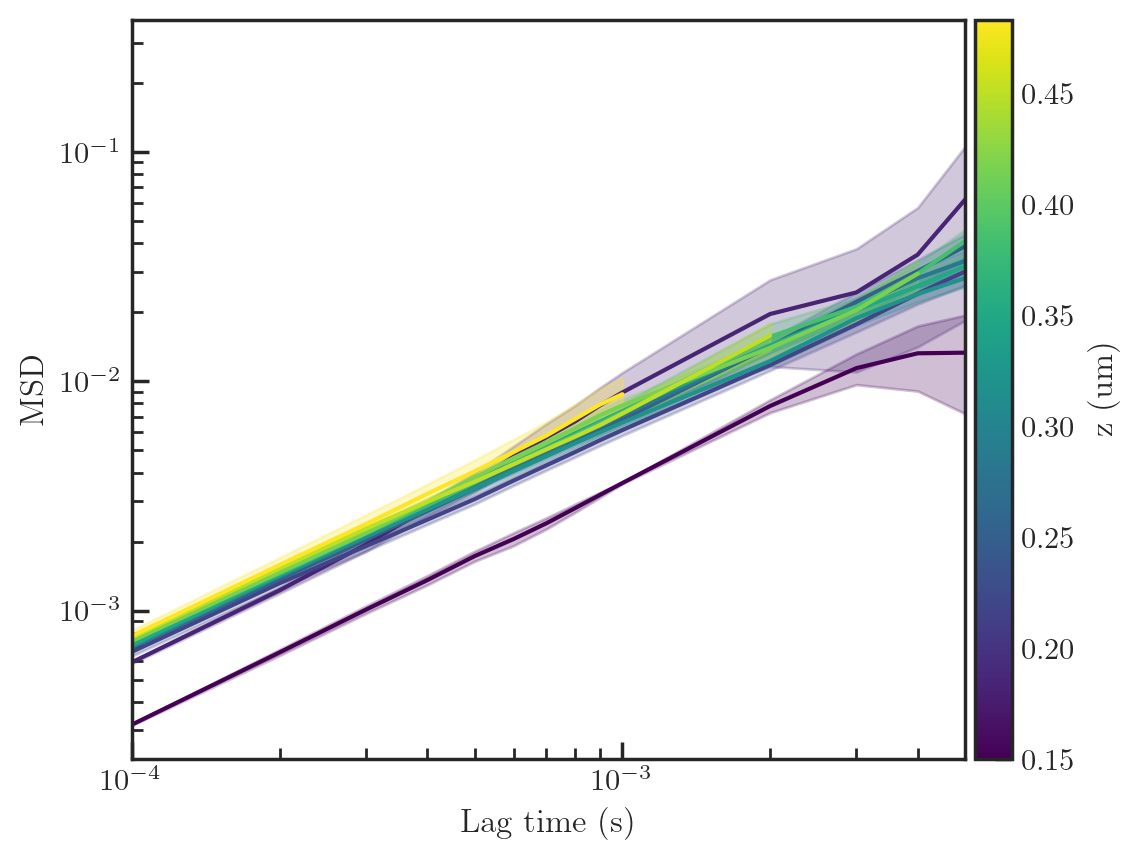

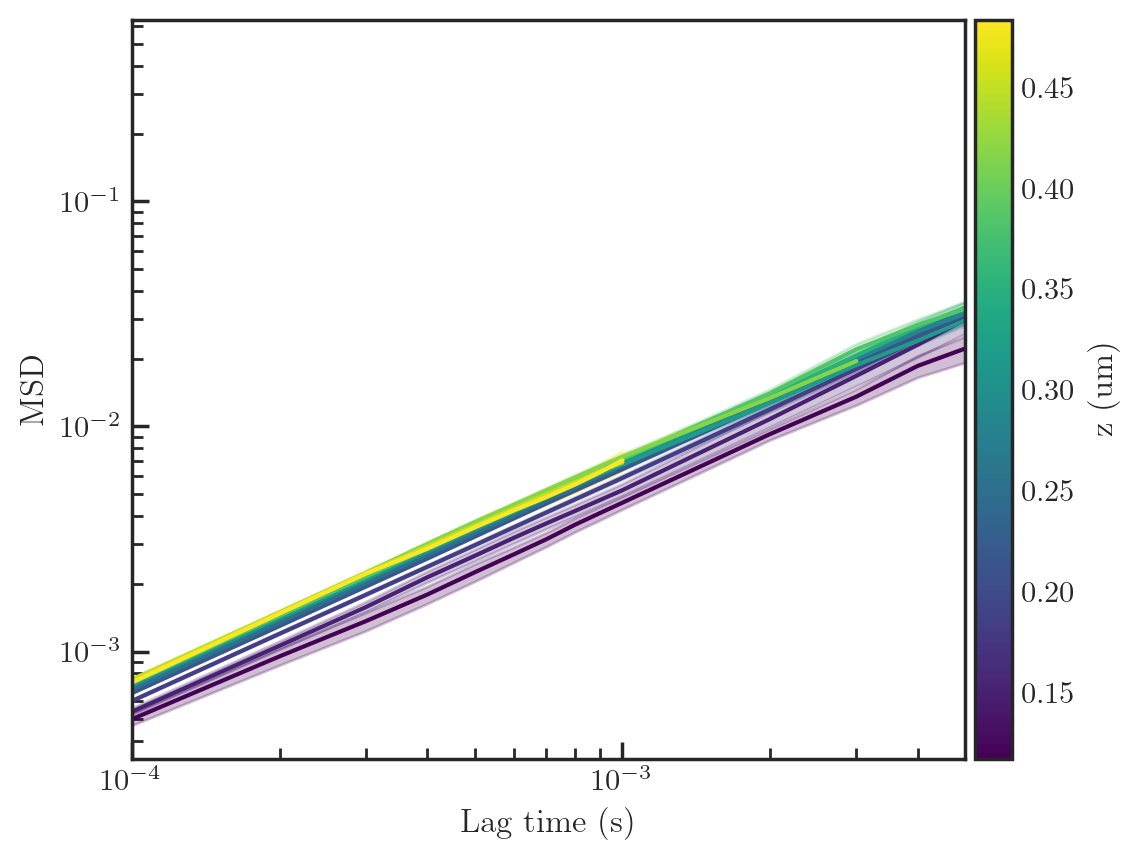

In [ ]:
import parameters

t_min = parameters.time_step
dt = parameters.time_step

t_max = 1e-3
z_threshold = 2.0  # parameters.evanescent_slice_z_height * parameters.m_to_um

for nameshear in np.sort(os.listdir(".")):
    if os.path.isdir(nameshear) and nameshear.startswith("shear="):

        for namephi in os.listdir(nameshear):
            phi_path = os.path.join(nameshear, namephi)

            if os.path.isdir(phi_path) and namephi.startswith("phi="):

                folder = f"{nameshear}/{namephi}"
                out_json = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{folder}/D_per_height.json"

                # Skip if the exact output file already exists
                # if os.path.exists(out_json):
                #     print(f"Skipping {folder}: D_per_height.json already exists.")
                #     continue

                config = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{folder}/run_blobs.sphere_array.config"
                frames, num_particles = parse_config(config)
                trajs = frames_to_trajectories(frames)
                segments_per_particle = split_by_z_threshold(
                    trajs, z_threshold=z_threshold, inclusive=True, min_len=10
                )

                signals = [seg for parts in segments_per_particle for seg in parts]

                # signals = [] ### possible to concatenate everythin with the line above !
                # for parts in segments_per_particle:
                # for seg in parts:
                # signals.append(seg)

                bins, edges = identify_trajectories_per_avg_height(
                    signals,
                    debye_height=0.1,
                    evanescent_height=z_threshold,
                    how_many_bins=12,
                )

                bin_centers, taus_list, msd_mean, msd_sem = average_msd_per_bin(
                    bins=bins, bin_edges=edges, comp="y", dt=dt
                )

                do_fit_MSD(
                    bin_centers,
                    taus_list,
                    msd_mean,
                    t_min=t_min,
                    t_max=t_max,
                    save_json_path=out_json,
                )

                print(
                    do_fit_MSD(
                        bin_centers,
                        taus_list,
                        msd_mean,
                        t_min=t_min,
                        t_max=t_max,
                        save_json_path=out_json,
                    )
                )

                plot_msd_curves_per_bin(
                    bin_centers, taus_list, msd_mean, msd_sem, cmap_name="viridis"
                )

# Plotting D(y=inf) = f(tau)

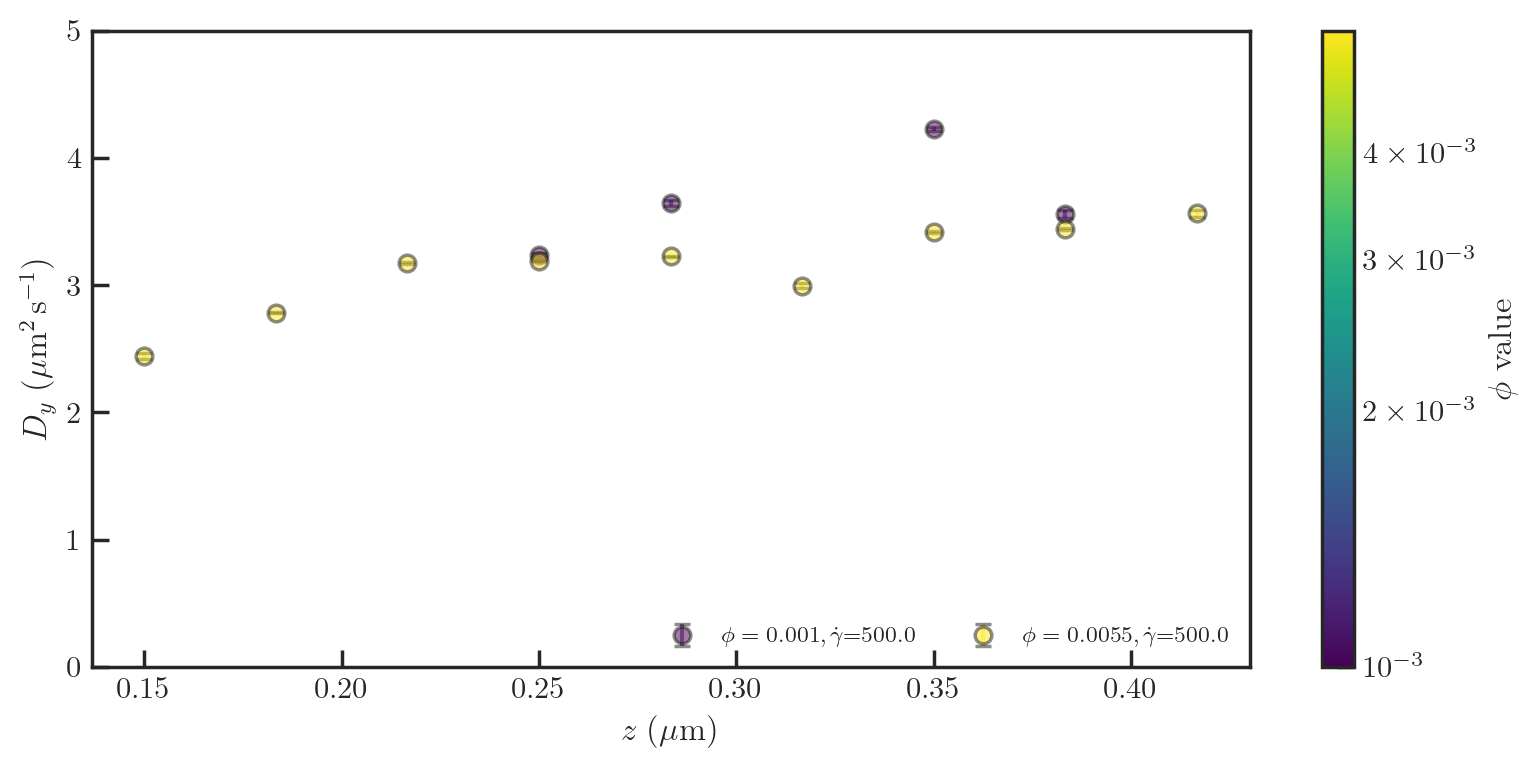

In [ ]:
plot_diffusion_multiple_phi("D_per_height.json")

# MSD plots now turned into D plots as Dy = f(z, t)

comp = "y"
dt = 1e-4
t_min, t_max = dt, 1e-1

tmax_array = np.linspace(10 * t_min, t_max, 5)

z_threshold = .5



for name in np.sort(os.listdir(".")):
    if os.path.isdir(name) and name.startswith("phi="):
        for t in tmax_array :
            config = f"/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/{name}/run_blobs.sphere_array.config" 
            frames, num_particles = parse_config(config) 
            trajs = frames_to_trajectories(frames)
            segments_per_particle = split_by_z_threshold(trajs, z_threshold=z_threshold, inclusive=True, min_len=10) 



            signals = [seg for parts in segments_per_particle for seg in parts]


            bins, edges = identify_trajectories_per_avg_height(
                signals, debye_height=.1, evanescent_height=z_threshold, how_many_bins=12 
            )

            bin_centers, taus_list, msd_mean, msd_sem = average_msd_per_bin(
                bins=bins, bin_edges=edges, comp=comp, dt=dt,
            )

            do_fit_MSD(bin_centers, taus_list, msd_mean, t_min=t_min, t_max=t, save_json_path=f"./{name}/D_per_height_tmax={t}.json")





fig, ax = plot_msd_curves_per_bin(
bin_centers, taus_list, msd_mean, msd_sem,
cmap_name="viridis"
)
            
fig, ax = plot_D_curves_per_bin(
bin_centers[1:], taus_list[1:], msd_mean[1:], msd_sem[1:],
cmap_name="viridis"
)

In [ ]:
import json
import numpy as np
import os

tmax_vals = []
D_vals = []
std_vals = []

for name in np.sort(os.listdir(".")):
    if os.path.isdir(name) and name.startswith("phi="):
        for Dfile in np.sort(os.listdir(f"./{name}")):
            if Dfile.startswith("D_per_height"):
                filepath = os.path.join(name, Dfile)
                with open(filepath, "r") as f:
                    data = json.load(f)

                keys = sorted(data.keys(), key=float)
                penultimate_key = keys[-2]
                penultimate_bin = data[penultimate_key]

                D = penultimate_bin["D"]
                std = penultimate_bin["stdD"]

                tmax_str = Dfile.split("tmax=")[1].split(".json")[0]
                tmax = float(tmax_str)

                tmax_vals.append(tmax)
                D_vals.append(D)
                std_vals.append(std)

tmax_vals = np.array(tmax_vals)
D_vals = np.array(D_vals)
std_vals = np.array(std_vals)

order = np.argsort(tmax_vals)
tmax_vals = tmax_vals[order]
D_vals = D_vals[order]
std_vals = std_vals[order]

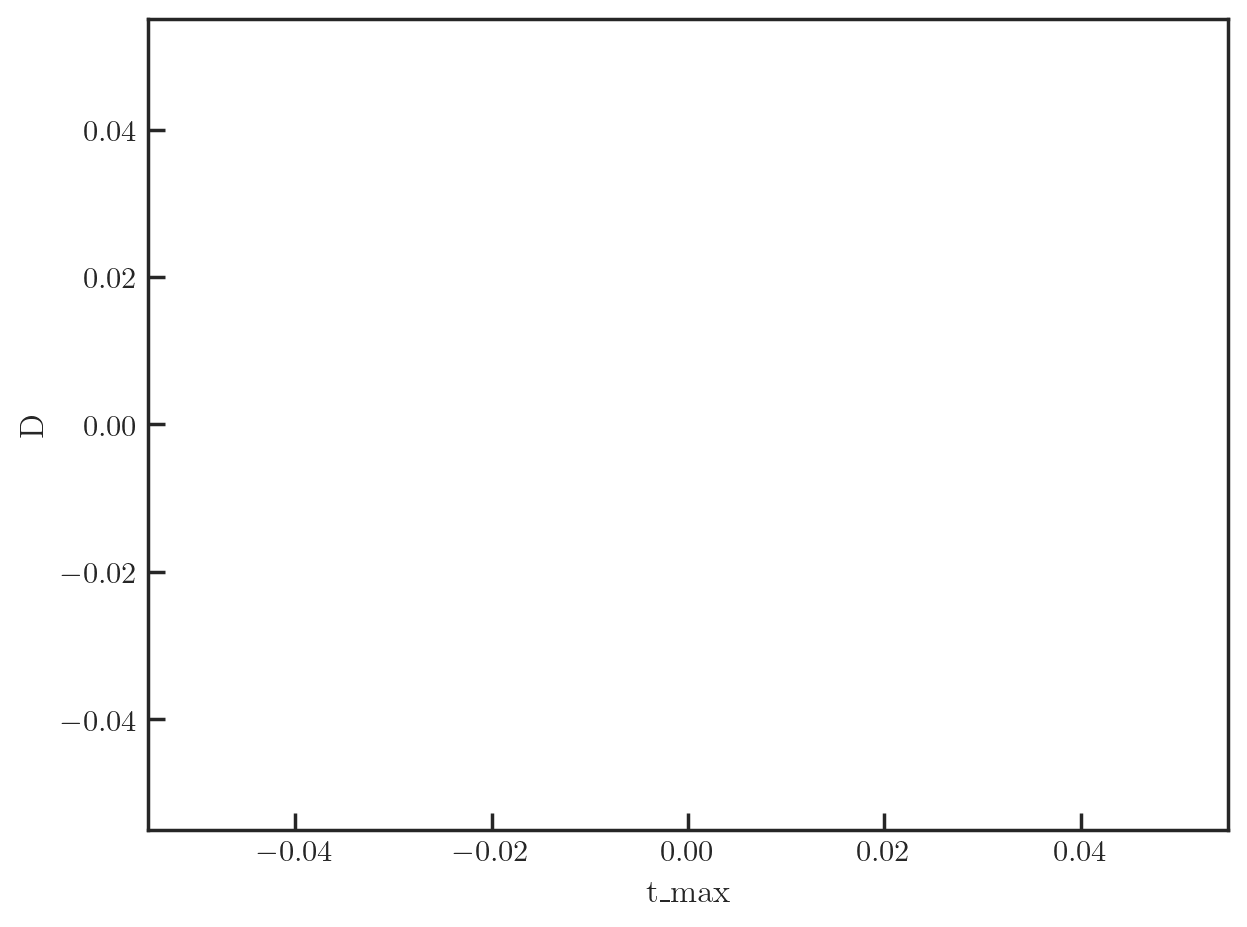

In [ ]:
plt.errorbar(tmax_vals, D_vals, yerr=std_vals, fmt="o")
plt.xlabel("t_max")
plt.ylabel("D")
plt.tight_layout()
plt.show()